# Incendios forestales en España

Descripción de la base de datos: La base de datos contiene el historico de incendios en España categorizado por municipios como a su vez la cantidad de muertos y heridos que se registro.

Archivo donde se analizo la información: fires-all.csv

Columnas de interes:
1. fecha: Fecha en la que se registro loa incendios
2. idmunicipio
3. municipio: Municipio afectado por los incendios
4. muertos: Muertos registrados
5. heridos: Heridos registrados
6. perdidas: Perdidas registradas

In [1]:
import pandas as pd
df = pd.read_csv('fires-all.csv')

Se eliminan columas innecesarias para un mejor analisis(contenian datos vacios):

In [2]:
df.drop(columns=['id','lat', 'lng', 'latlng_explicit'], inplace=True)

Para una visualización general de la información se visualizan los primeros 20 registros debido a que la base de datos tiene arriba de 100,000 registros

In [3]:
df.head(20)

,superficie,fecha,idcomunidad,idprovincia,idmunicipio,municipio,causa,causa_supuesta,causa_desc,muertos,heridos,time_ctrl,time_ext,personal,medios,gastos,perdidas
0,14.0,1968-01-01,4,29,0,INDETERMINADO,2,1,40,0,0,0,360,0,0,0,0
1,3.0,1968-01-03,2,43,0,INDETERMINADO,5,1,0,0,0,0,60,0,0,0,0
2,2.0,1968-01-06,4,29,0,INDETERMINADO,5,1,0,0,0,0,120,0,0,0,0
3,8.2,1968-01-07,9,12,0,INDETERMINADO,3,1,20,0,0,0,120,0,0,0,0
4,600.0,1968-01-07,2,43,0,INDETERMINADO,3,1,20,0,0,0,1440,35,1,0,0
5,1.0,1968-01-07,9,46,0,INDETERMINADO,5,1,0,0,0,0,120,0,0,0,0
6,1.8,1968-01-09,2,43,0,INDETERMINADO,2,1,40,0,0,0,120,0,0,0,0
7,1.5,1968-01-09,10,44,0,INDETERMINADO,2,1,40,0,0,0,120,0,0,0,0
8,35.0,1968-01-10,2,25,0,INDETERMINADO,4,1,99,0,0,0,1440,39,0,0,0
9,1.0,1968-01-10,17,49,0,INDETERMINADO,2,1,40,0,0,0,60,0,0,0,0


Al revisar la información de la base de datos de incendios en España, se realizo un analisis de cuentos incendios por municipio, donde traigo  los primeros 50 municipios.

Una vez hecho esto se observa que el municipio con mas incendios es el "Indeterminado", dicha información se visualizara por medio de graficas:

In [4]:
municipios = df.municipio.value_counts()
municipios.head(50)

municipio
INDETERMINADO               54382
CANGAS DEL NARCEA            2261
PILOÑA                       2109
TINEO                        1812
VIANA DO BOLO                1716
LLANES                       1614
GUDIÑA, A                    1345
ALLANDE                      1323
CANGAS DE ONÍS               1243
LENA                         1206
MUIÑOS                       1178
CABUÉRNIGA                   1154
CAÑIZA, A                    1122
CHANDREXA DE QUEIXA          1050
MANZANEDA                     944
CERVANTES                     913
MEZQUITA, A                   895
COTOBADE                      887
ALLER                         877
VEGA DE PAS                   866
GRADO                         830
FORCAREI                      810
BELMONTE DE MIRANDA           785
CARBALLEDA DE VALDEORRAS      783
VILARIÑO DE CONSO             773
CASTRO CALDELAS               756
BADAJOZ                       753
IBIAS                         750
MONDARIZ                      749
ESTR

In [5]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'Top 20 de Municipios de incendios'}, xlabel='municipio'>

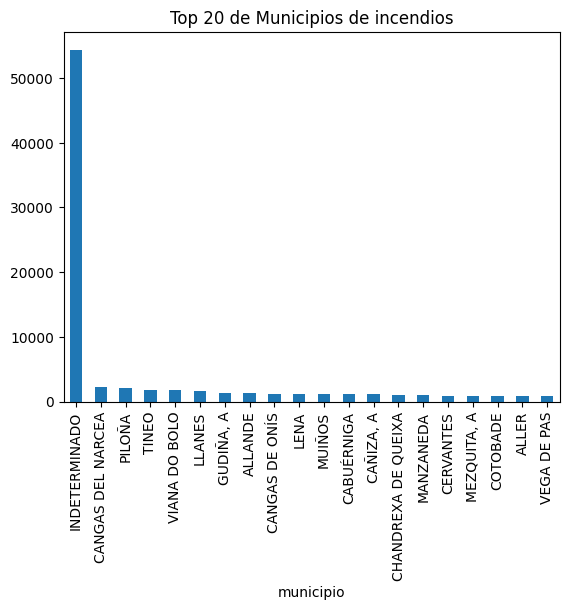

In [6]:
plt.title('Top 20 de Municipios de incendios')
municipios.head(20).plot.bar()

Para una mejor apreciación y comparativa de la información consultaremos los municipios con incendios sin considerar el municipio INDETERMINADO.

In [7]:
municipios_exactos = df[ df['municipio'] != 'INDETERMINADO']
municipios_exactos.head(20)

,superficie,fecha,idcomunidad,idprovincia,idmunicipio,municipio,causa,causa_supuesta,causa_desc,muertos,heridos,time_ctrl,time_ext,personal,medios,gastos,perdidas
39655,20.0,1980-09-18,3,32,9,"BARCO DE VALDEORRAS, O",4,1,99,0,0,0,420,12,0,0,1
54383,2.0,1983-01-04,9,46,150,LUTXENT,5,1,0,0,0,0,180,13,0,0,0
54384,15.0,1983-01-05,10,44,201,RUBIELOS DE MORA,2,1,90,0,0,0,360,78,0,1,0
54385,15.0,1983-01-05,9,46,115,DOS AGUAS,5,1,0,0,0,0,300,63,1,0,2
54386,95.0,1983-01-06,9,12,105,SIERRA ENGARCERÁN,4,1,99,0,0,0,1440,22,0,0,0
54387,10.0,1983-01-06,6,39,39,LUENA,4,1,99,0,0,0,840,10,0,0,0
54388,6.0,1983-01-06,9,46,36,ALPUENTE,5,1,0,0,0,0,480,10,0,0,0
54389,20.0,1983-01-07,2,17,139,"PRESES, LES",5,1,0,0,0,0,540,45,4,0,1
54390,4.0,1983-01-08,9,12,80,MORELLA,4,1,99,0,0,0,660,26,2,0,0
54391,3.0,1983-01-08,9,12,12,ALTURA,5,1,0,0,0,0,120,0,0,0,1


<Axes: title={'center': 'TOP municipios veridicos'}, xlabel='municipio'>

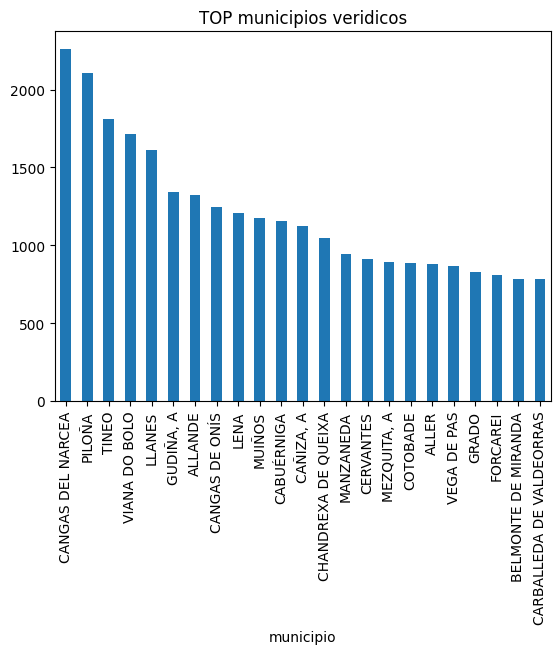

In [12]:
barras = municipios_exactos.municipio.value_counts()
plt.title('TOP municipios veridicos')
barras.head(23).plot.bar()

De acuerdo a la grafica los otro estados con mayor cantidad de incendios son en:
1. Cangas del narcea
2. Piloña
3. Tineo
4. Viana do bolo

Otro dato de interes es conocer la cantidad de incendios por año, por lo cual se decidio sacar las estadisticas:

In [9]:
df['fecha'] = pd.to_datetime(df['fecha'])
df['anio'] = df['fecha'].dt.year
df.groupby('anio')['anio'].count().head(28)

anio
1968     1464
1969     1088
1970     2358
1971     1255
1972     1606
1973     2974
1974     3232
1975     3331
1976     3549
1977     1569
1978     7151
1979     5241
1980     5870
1981     8789
1982     4906
1983     3404
1984     5614
1985    10119
1986     5665
1987     6455
1988     6743
1989    15922
1990     8413
1991     7450
1992     7337
1993     4984
1994     8288
1995    10146
Name: anio, dtype: int64

In [10]:
df.groupby('anio')['anio'].count().tail(28)

anio
1996    5775
1997    8184
1998    7944
1999    6489
2000    9345
2001    6927
2002    7819
2003    6634
2004    7646
2005    9017
2006    5593
2007    3413
2008    4355
2009    5777
2010    3910
2011    5599
2012    5542
2013    3089
2014    3196
2015    4125
2016    2432
2017    5223
2018    2004
2019    3796
2020    2287
2021     888
2022     226
2023      23
Name: anio, dtype: int64

De acuerdo a dichas estadisticas vemos lo siguiente:
* Que los años donde se presento una cantidad considerable es en los años 1985, 1989 y 1995; con una cantidad mayor de 10,000 incendios.
* En los ultimos tres años la cantidad anual de incendio bajo

### Muertos, heridos y perdidas

Para la cantidad muertos se observa que se concentra mas en los estados:
1. Hermigua
2. Riba de Saelices
3. Millares

<Axes: title={'center': 'Muertos por estado'}, ylabel='municipio'>

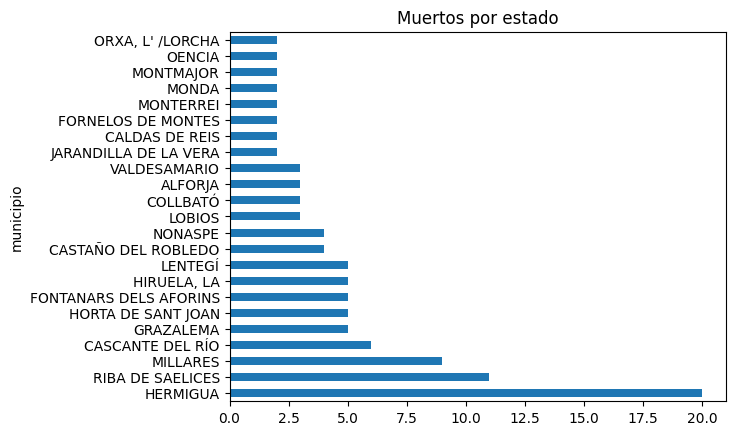

In [19]:
muertos = municipios_exactos.groupby('municipio')['muertos'].sum().sort_values(ascending=False)
plt.title('Muertos por estado')
muertos.head(23).plot.barh()

Para la cantidad de heridos los estados donde se presento mas este incide fueron en:
1. Montmajor
2. Velez de Benaudalla
3. San Roque

<Axes: title={'center': 'Heridos por estado'}, ylabel='municipio'>

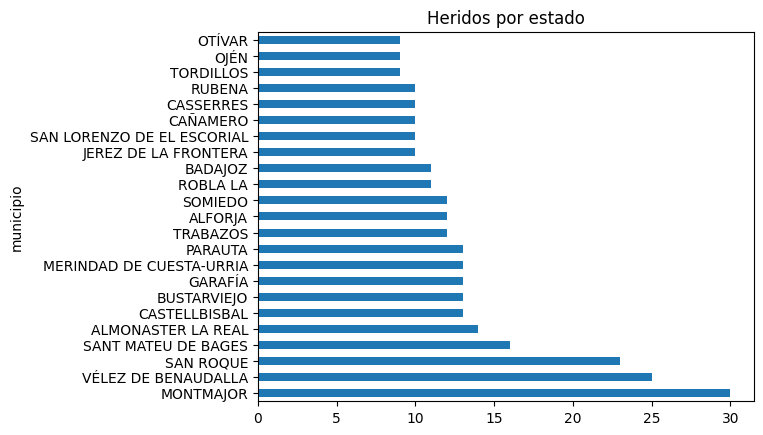

In [22]:
heridos = municipios_exactos.groupby('municipio')['heridos'].sum().sort_values(ascending=False)
plt.title('Heridos por estado')
heridos.head(23).plot.barh()

Para la cantidad de heridos los estados donde se presento mas este incide fueron en:
1. Otra provincia
2. Sant mateu de bages
3. Lobios

<Axes: title={'center': 'Total de perdidas por estado'}, ylabel='municipio'>

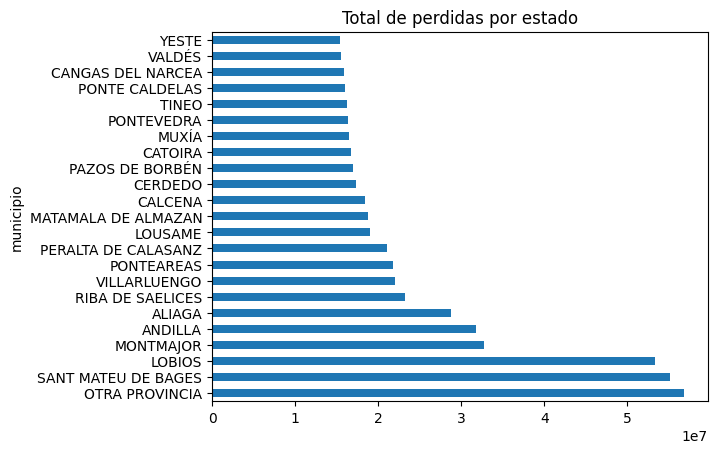

In [25]:
perdidas = municipios_exactos.groupby('municipio')['perdidas'].sum().sort_values(ascending=False)
plt.title('Total de perdidas por estado')
perdidas.head(23).plot.barh()